# Gaming Statistical Analysis

Notebook for loading, cleaning, and analyzing Playnite gaming library data with descriptive statistics and visualizations.

## Libraries and setup

This cell imports the required libraries (pandas, numpy, matplotlib, seaborn, scipy) and sets the default plot style.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set figure size for portrait orientation
plt.rcParams['figure.figsize'] = (10, 12)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Load dataset

This cell loads the CSV dataset and prints basic info plus the first five rows.

In [74]:
# Load raw dataset
df = pd.read_csv('Playnite_Data_02-07-2026.csv')

print("="*80)
print("DATA LOADING")
print("="*80)
print(f"Dataset loaded successfully!")
print(f"Total records: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumns in dataset: {list(df.columns)}")
print(f"\nFirst few rows:")
display(df.head())
print(f"{'='*80}")

DATA LOADING
Dataset loaded successfully!
Total records: 79
Total columns: 9

Columns in dataset: ['Name', 'Categories', 'Added', 'Last Played', 'Recent Activity', 'Completion Status', 'Platforms', 'Play Count', 'Time Played']

First few rows:


,Name,Categories,Added,Last Played,Recent Activity,Completion Status,Platforms,Play Count,Time Played
0,2XKO,Fighting,10/28/2025 0:12,10/28/2025 18:08,10/28/2025 18:08,Played,PC (Windows),4,7323
1,Back 4 Blood,Survival,11/30/2024 0:00,12/5/2024 0:00,12/5/2024 0:00,Played,PC (Windows),6,32640
2,Battlefield V,Shooter,2/6/2026 19:14,8/14/2025 0:00,2/6/2026 19:14,Played,PC (Windows),2,7380
3,Century: Age of Ashes,Shooter,5/17/2024 0:00,5/17/2024 0:00,5/17/2024 0:00,Played,PC (Windows),1,4200
4,Cities: Skylines,Simulation,6/15/2023 0:00,6/19/2023 0:00,6/19/2023 0:00,Played,PC (Windows),7,12060


## Time Played to hours

This cell converts Time Played from seconds to hours using the formula H = S/3600.

In [75]:
# D.1: Unit Normalization
# Transform Time Played from seconds to hours using formula: H = S / 3600
# This allows for more relatable interpretation (e.g., 1098300 seconds = 305.08 hours)
df['Time Played Hours'] = df['Time Played'] / 3600

# Show example conversion
example_idx = df['Time Played'].notna().idxmax()
if pd.notna(df.loc[example_idx, 'Time Played']):
    example_seconds = df.loc[example_idx, 'Time Played']
    example_hours = df.loc[example_idx, 'Time Played Hours']
    print("="*80)
    print("D.1: UNIT NORMALIZATION")
    print("="*80)
    print(f"Example conversion: {example_seconds:.0f} seconds = {example_hours:.2f} hours")
    print(f"Formula applied: H = S / 3600")
    print(f"✓ Time Played converted from seconds to hours")
    print(f"{'='*80}")

D.1: UNIT NORMALIZATION
Example conversion: 7323 seconds = 2.03 hours
Formula applied: H = S / 3600
✓ Time Played converted from seconds to hours


## Category correction

This cell strips whitespace and corrects category name typos for consistent grouping.

In [76]:
# D.2: Categorical Correction
print("D.2: CATEGORICAL CORRECTION")
print("="*80)
print(f"Categories before correction:")
print(df['Categories'].value_counts())

# Remove leading/trailing spaces
df['Categories'] = df['Categories'].str.strip()

# Fix typographical errors
category_mapping = {
    'Fighting ': 'Fighting',
    'Shooter ': 'Shooter',
    'Survival ': 'Survival',
    'Simulation ': 'Simulation',
    'Action ': 'Action',
    'Arcade ': 'Arcade',
    'RPG ': 'RPG'
}
df['Categories'] = df['Categories'].replace(category_mapping)

print(f"\nCategories after correction:")
print(df['Categories'].value_counts())
print(f"\n✓ Typographical errors corrected")
print(f"{'='*80}")

D.2: CATEGORICAL CORRECTION
Categories before correction:
Categories
Action        18
Shooter       14
Arcade        13
Survival      10
Simulation     9
RPG            8
Fighting       7
Name: count, dtype: int64

Categories after correction:
Categories
Action        18
Shooter       14
Arcade        13
Survival      10
Simulation     9
RPG            8
Fighting       7
Name: count, dtype: int64

✓ Typographical errors corrected


## Missing categories imputation

This cell fills missing Categories with 'Uncategorized' to preserve the full sample size.

In [77]:
# D.3: Missing Value Imputation
# For games with missing Categories, apply "Uncategorized" label
# This maintains complete 79-title sample size
missing_categories_before = df['Categories'].isna().sum()

print("="*80)
print("D.3: MISSING VALUE IMPUTATION")
print("="*80)
print(f"Missing Categories before imputation: {missing_categories_before}")

# Apply "Uncategorized" label to missing values
df['Categories'] = df['Categories'].fillna('Uncategorized')

missing_categories_after = df['Categories'].isna().sum()
print(f"Missing Categories after imputation: {missing_categories_after}")
print(f"Sample size maintained: {len(df)} titles")
print(f"\n✓ Missing values imputed with 'Uncategorized' label")
print(f"{'='*80}")

D.3: MISSING VALUE IMPUTATION
Missing Categories before imputation: 0
Missing Categories after imputation: 0
Sample size maintained: 79 titles

✓ Missing values imputed with 'Uncategorized' label


## Dates and status filter

This cell parses date columns and filters to played games with at least one session (Play Count > 0).

In [78]:
# D.4: Status Filtering
# Separate games marked as "Plan to Play" for backlog analysis
# Convert date columns for temporal analysis (parse then keep date only - remove time)
date_columns = ['Added', 'Last Played', 'Recent Activity']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce').dt.normalize()  # time set to 00:00:00, date only

print("="*80)
print("D.4: STATUS FILTERING")
print("="*80)

# Filter games by Completion Status
df_played_status = df[df['Completion Status'] == 'Played'].copy()
df_backlog = df[df['Completion Status'] == 'Plan to Play'].copy()

print(f"Total games in library: {len(df)}")
print(f"\nGames with 'Played' status: {len(df_played_status)}")
print(f"Games with 'Plan to Play' status (Digital Backlog): {len(df_backlog)}")

# Main analysis dataset: Games with 'Played' status AND Play Count > 0
# This represents games that have been actively played
df_played = df_played_status[df_played_status['Play Count'] > 0].copy()
df_played_zero_sessions = df_played_status[df_played_status['Play Count'] == 0].copy()

print(f"\nMain analysis dataset (Played games with sessions, Play Count > 0): {len(df_played)}")
print(f"Played games with zero sessions (Play Count = 0): {len(df_played_zero_sessions)}")

print(f"\n✓ Status filtering completed")
print(f"✓ Date columns converted to date only (time removed): Added, Last Played, Recent Activity")
print(f"✓ Main analysis dataset prepared: {len(df_played)} games")
print(f"{'='*80}")

D.4: STATUS FILTERING
Total games in library: 79

Games with 'Played' status: 72
Games with 'Plan to Play' status (Digital Backlog): 0

Main analysis dataset (Played games with sessions, Play Count > 0): 72
Played games with zero sessions (Play Count = 0): 0

✓ Status filtering completed
✓ Date columns converted to date only (time removed): Added, Last Played, Recent Activity
✓ Main analysis dataset prepared: 72 games


## Preprocessing summary

This cell prints a short summary of all data cleaning and preprocessing steps applied.

In [79]:
# Summary of Data Cleaning and Preprocessing
print("="*80)
print("DATA CLEANING AND PREPROCESSING SUMMARY")
print("="*80)
print(f"\n1. Unit Normalization:")
print(f"   ✓ Time Played converted from seconds to hours (H = S / 3600)")
print(f"\n2. Categorical Correction:")
print(f"   ✓ Typographical errors fixed (e.g., 'Fighthing' -> 'Fighting')")
print(f"   ✓ Leading/trailing spaces removed")
print(f"\n3. Missing Value Imputation:")
print(f"   ✓ Missing Categories labeled as 'Uncategorized'")
print(f"   ✓ Sample size maintained: {len(df)} titles")
print(f"\n4. Status Filtering:")
print(f"   ✓ 'Played' games: {len(df_played)} titles")
print(f"   ✓ 'Plan to Play' games (Backlog): {len(df_backlog)} titles")
print(f"   ✓ Date columns converted to datetime format")
print(f"\n{'='*80}")
print(f"\nDataset ready for statistical analysis!")
print(f"Primary analysis dataset: {len(df_played)} games (Played status with Play Count > 0)")
print(f"{'='*80}")

DATA CLEANING AND PREPROCESSING SUMMARY

1. Unit Normalization:
   ✓ Time Played converted from seconds to hours (H = S / 3600)

2. Categorical Correction:
   ✓ Typographical errors fixed (e.g., 'Fighthing' -> 'Fighting')
   ✓ Leading/trailing spaces removed

3. Missing Value Imputation:
   ✓ Missing Categories labeled as 'Uncategorized'
   ✓ Sample size maintained: 79 titles

4. Status Filtering:
   ✓ 'Played' games: 72 titles
   ✓ 'Plan to Play' games (Backlog): 0 titles
   ✓ Date columns converted to datetime format


Dataset ready for statistical analysis!
Primary analysis dataset: 72 games (Played status with Play Count > 0)


## Overall dataset overview

This cell prints total games, completion status counts, unique platforms and categories.

In [80]:
# Overall dataset summary
print("="*80)
print("OVERALL DATASET OVERVIEW")
print("="*80)
print(f"\nTotal games in library: {len(df)}")
print(f"\nGames by Completion Status:")
print(f"  - 'Played' status: {len(df_played_status)} games")
print(f"    • With active sessions (Play Count > 0): {len(df_played)} games")
print(f"    • With zero sessions (Play Count = 0): {len(df_played_zero_sessions)} games")
print(f"  - 'Plan to Play' status (Digital Backlog): {len(df_backlog)} games")
print(f"\nUnique platforms: {df['Platforms'].nunique()}")
print(f"Unique categories: {df['Categories'].nunique()}")
print(f"\nPlatforms: {', '.join(sorted(df['Platforms'].unique()))}")
print(f"\nCategories: {', '.join(sorted(df['Categories'].unique()))}")
print(f"\n{'='*80}")
print(f"\nNote: Main analysis focuses on {len(df_played)} games with 'Played' status and Play Count > 0")
print(f"{'='*80}")

OVERALL DATASET OVERVIEW

Total games in library: 79

Games by Completion Status:
  - 'Played' status: 72 games
    • With active sessions (Play Count > 0): 72 games
    • With zero sessions (Play Count = 0): 0 games
  - 'Plan to Play' status (Digital Backlog): 0 games

Unique platforms: 6
Unique categories: 7

Platforms: Nintendo Switch, Nintendo Switch 2, PC (Windows), Sony PlayStation 3, Sony PlayStation 4, Sony PlayStation 5

Categories: Action, Arcade, Fighting, RPG, Shooter, Simulation, Survival


Note: Main analysis focuses on 72 games with 'Played' status and Play Count > 0


## Descriptive statistics

This cell computes mean, median, standard deviation, skewness and kurtosis for Time Played Hours and Play Count, and saves Table 1.

In [81]:
# Calculate comprehensive descriptive statistics
numeric_vars = ['Time Played Hours', 'Play Count']

# Create Table 1 in portrait orientation (transposed)
descriptive_stats = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Standard Deviation', 'Minimum', 'Maximum', '25th Percentile', '75th Percentile', 'Skewness', 'Kurtosis'],
    'Time Played (Hours)': [
        df_played['Time Played Hours'].mean(),
        df_played['Time Played Hours'].median(),
        df_played['Time Played Hours'].std(),
        df_played['Time Played Hours'].min(),
        df_played['Time Played Hours'].max(),
        df_played['Time Played Hours'].quantile(0.25),
        df_played['Time Played Hours'].quantile(0.75),
        df_played['Time Played Hours'].skew(),
        df_played['Time Played Hours'].kurtosis()
    ],
    'Play Count': [
        df_played['Play Count'].mean(),
        df_played['Play Count'].median(),
        df_played['Play Count'].std(),
        df_played['Play Count'].min(),
        df_played['Play Count'].max(),
        df_played['Play Count'].quantile(0.25),
        df_played['Play Count'].quantile(0.75),
        df_played['Play Count'].skew(),
        df_played['Play Count'].kurtosis()
    ]
})

descriptive_stats = descriptive_stats.round(2)

print("="*80)
print("TABLE 1: COMPREHENSIVE DESCRIPTIVE STATISTICS")
print("="*80)
print(f"Sample size (played games): {len(df_played)}")
print("\n")
display(descriptive_stats)

# Save table
descriptive_stats.to_csv('Table1_Descriptive_Statistics.csv', index=False)
print("\n✓ Table 1 saved as 'Table1_Descriptive_Statistics.csv'")

# Interpretation
print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print(f"Time Played Hours:")
print(f"  - Mean ({descriptive_stats.loc[0, 'Time Played (Hours)']:.2f} hours) is {'greater' if descriptive_stats.loc[0, 'Time Played (Hours)'] > descriptive_stats.loc[1, 'Time Played (Hours)'] else 'less'} than median ({descriptive_stats.loc[1, 'Time Played (Hours)']:.2f} hours), indicating {'right' if descriptive_stats.loc[0, 'Time Played (Hours)'] > descriptive_stats.loc[1, 'Time Played (Hours)'] else 'left'}-skewed distribution")
print(f"  - Standard deviation ({descriptive_stats.loc[2, 'Time Played (Hours)']:.2f} hours) shows {'high' if descriptive_stats.loc[2, 'Time Played (Hours)'] > descriptive_stats.loc[0, 'Time Played (Hours)'] else 'moderate'} variability")
print(f"  - Skewness ({descriptive_stats.loc[7, 'Time Played (Hours)']:.2f}) indicates {'strong right' if descriptive_stats.loc[7, 'Time Played (Hours)'] > 1 else 'moderate right' if descriptive_stats.loc[7, 'Time Played (Hours)'] > 0.5 else 'near-normal' if abs(descriptive_stats.loc[7, 'Time Played (Hours)']) < 0.5 else 'left'}-skewed distribution")
print(f"\nPlay Count:")
print(f"  - Mean ({descriptive_stats.loc[0, 'Play Count']:.2f} sessions) is {'greater' if descriptive_stats.loc[0, 'Play Count'] > descriptive_stats.loc[1, 'Play Count'] else 'less'} than median ({descriptive_stats.loc[1, 'Play Count']:.2f} sessions)")
print(f"  - Standard deviation ({descriptive_stats.loc[2, 'Play Count']:.2f} sessions) indicates {'high' if descriptive_stats.loc[2, 'Play Count'] > descriptive_stats.loc[0, 'Play Count'] else 'moderate'} variability")
print(f"  - Skewness ({descriptive_stats.loc[7, 'Play Count']:.2f}) indicates {'strong right' if descriptive_stats.loc[7, 'Play Count'] > 1 else 'moderate right' if descriptive_stats.loc[7, 'Play Count'] > 0.5 else 'near-normal' if abs(descriptive_stats.loc[7, 'Play Count']) < 0.5 else 'left'}-skewed distribution")
print(f"{'='*80}")

TABLE 1: COMPREHENSIVE DESCRIPTIVE STATISTICS
Sample size (played games): 72




,Variable,Mean,Median,Standard Deviation,Minimum,Maximum,25th Percentile,75th Percentile,Skewness,Kurtosis
0,Time Played (Hours),29.20,3.81,82.96,0.0,570.58,1.31,13.80,4.90,27.44
1,Play Count,35.42,6.00,94.07,1.0,585.00,3.00,19.25,4.69,23.76



✓ Table 1 saved as 'Table1_Descriptive_Statistics.csv'

INTERPRETATION:
Time Played Hours:
  - Mean (29.20 hours) is greater than median (3.81 hours), indicating right-skewed distribution
  - Standard deviation (82.96 hours) shows high variability
  - Skewness (4.90) indicates strong right-skewed distribution

Play Count:
  - Mean (35.42 sessions) is greater than median (6.00 sessions)
  - Standard deviation (94.07 sessions) indicates high variability
  - Skewness (4.69) indicates strong right-skewed distribution


## Histograms: Time Played and Play Count

This cell plots histograms for Time Played Hours and Play Count with mean and median lines, and saves Figure 1 and Figure 2.

Figure 1: Distribution of Time Played Hours
✓ Figure 1 saved as 'Figure1_Distribution_Time_Played.png'


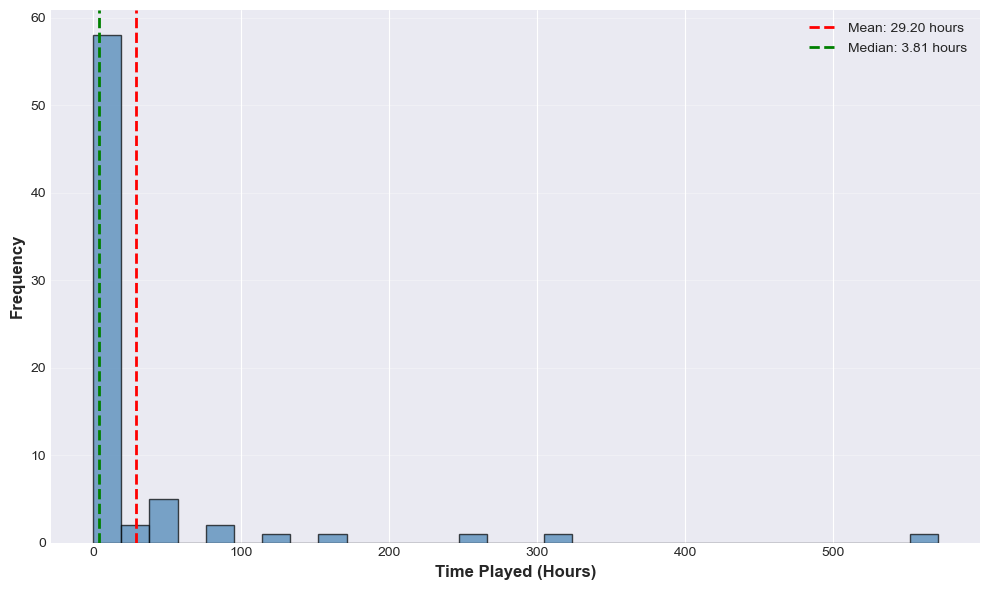

Figure 2: Distribution of Play Count
✓ Figure 2 saved as 'Figure2_Distribution_Play_Count.png'


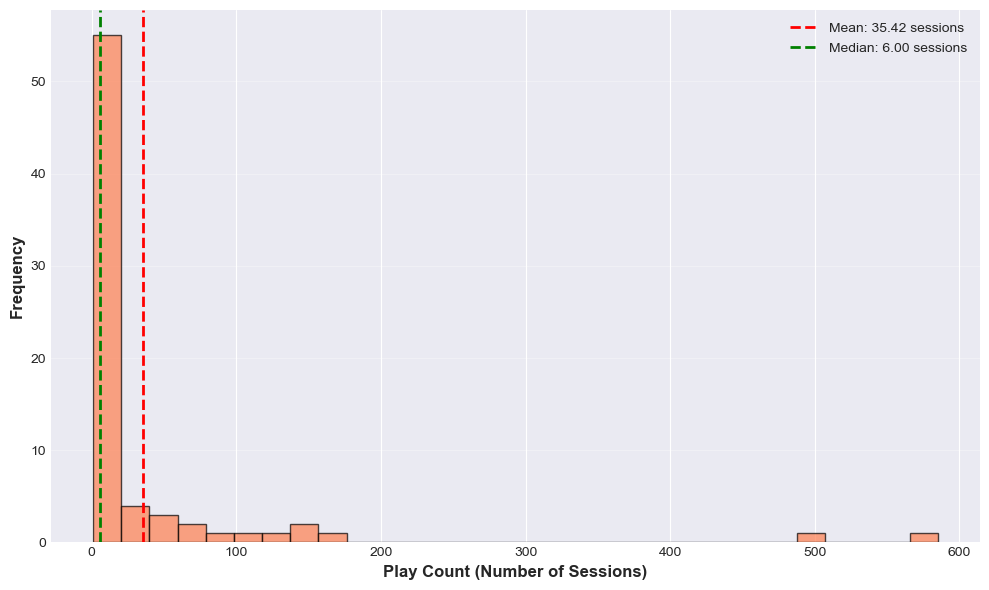

In [ ]:
print('Figure 1: Distribution of Time Played Hours')
# Figure 1: Distribution of Time Played Hours
fig1, ax1 = plt.subplots(figsize=(10, 6))

ax1.hist(df_played['Time Played Hours'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(df_played['Time Played Hours'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_played['Time Played Hours'].mean():.2f} hours")
ax1.axvline(df_played['Time Played Hours'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {df_played['Time Played Hours'].median():.2f} hours")
ax1.set_xlabel('Time Played (Hours)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Frequency', fontweight='bold', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Figure1_Distribution_Time_Played.png', dpi=300, bbox_inches='tight')
print("✓ Figure 1 saved as 'Figure1_Distribution_Time_Played.png'")
plt.show()

print('Figure 2: Distribution of Play Count')
# Figure 2: Distribution of Play Count
fig2, ax2 = plt.subplots(figsize=(10, 6))

ax2.hist(df_played['Play Count'], bins=30, color='coral', edgecolor='black', alpha=0.7)
ax2.axvline(df_played['Play Count'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_played['Play Count'].mean():.2f} sessions")
ax2.axvline(df_played['Play Count'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {df_played['Play Count'].median():.2f} sessions")
ax2.set_xlabel('Play Count (Number of Sessions)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Frequency', fontweight='bold', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Figure2_Distribution_Play_Count.png', dpi=300, bbox_inches='tight')
print("✓ Figure 2 saved as 'Figure2_Distribution_Play_Count.png'")
plt.show()

## Time-series: games added and playtime per year

This cell plots games added per year and total playtime per year (Figures 3 and 4).

Figure 3: Games Added to Library per Year (2021-2026)
✓ Figure 4 saved as 'Figure3_Games_Added_Per_Year.png'


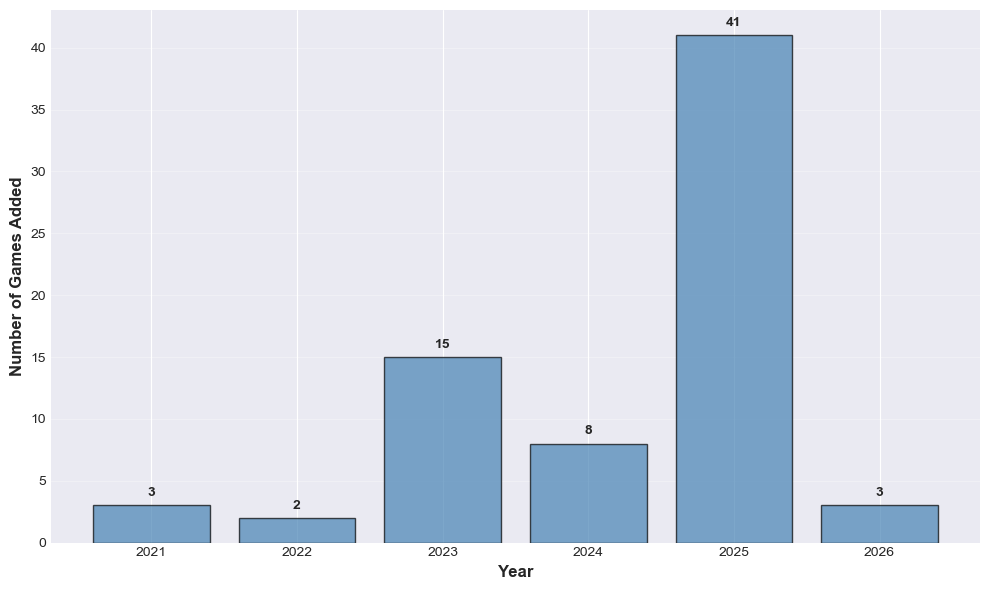

Figure 4: Total Playtime per Year (2021-2026)
✓ Figure 5 saved as 'Figure4_Total_Playtime_Per_Year.png'


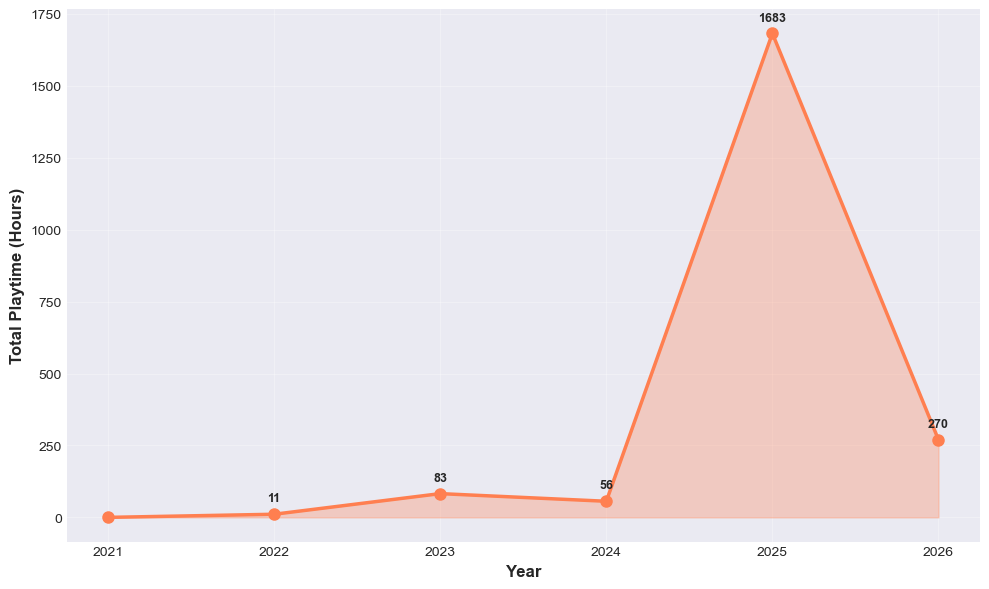


TIME-SERIES SUMMARY:
Peak year for games added: 2025 (41 games)
Peak year for playtime: 2025 (1683 hours)


In [ ]:
# Prepare time-series data
df_played['Year Added'] = df_played['Added'].dt.year
df_played['Year Last Played'] = df_played['Last Played'].dt.year

# Filter years 2021-2026
years_range = range(2021, 2027)

# Games added per year
games_added_per_year = df_played['Year Added'].value_counts().sort_index()
games_added_per_year = games_added_per_year.reindex(years_range, fill_value=0)

# Calculate playtime per year (approximate - using Last Played year as proxy)
playtime_per_year = df_played.groupby('Year Last Played')['Time Played Hours'].sum().sort_index()
playtime_per_year = playtime_per_year.reindex(years_range, fill_value=0)

print('Figure 3: Games Added to Library per Year (2021-2026)')
# Figure 3: Games Added to Library per Year
fig4, ax4 = plt.subplots(figsize=(10, 6))

ax4.bar(games_added_per_year.index, games_added_per_year.values, color='steelblue', edgecolor='black', alpha=0.7)
ax4.set_xlabel('Year', fontweight='bold', fontsize=12)
ax4.set_ylabel('Number of Games Added', fontweight='bold', fontsize=12)
# ax4 title removed — printed above
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_xticks(years_range)

# Add value labels
for year, count in games_added_per_year.items():
    if count > 0:
        ax4.text(year, count + 0.5, str(int(count)), ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('Figure3_Games_Added_Per_Year.png', dpi=300, bbox_inches='tight')
print("✓ Figure 4 saved as 'Figure3_Games_Added_Per_Year.png'")
plt.show()

print('Figure 4: Total Playtime per Year (2021-2026)')
# Figure 4: Total Playtime per Year
fig5, ax5 = plt.subplots(figsize=(10, 6))

ax5.plot(playtime_per_year.index, playtime_per_year.values, marker='o', linewidth=2.5, markersize=8, color='coral')
ax5.fill_between(playtime_per_year.index, playtime_per_year.values, alpha=0.3, color='coral')
ax5.set_xlabel('Year', fontweight='bold', fontsize=12)
ax5.set_ylabel('Total Playtime (Hours)', fontweight='bold', fontsize=12)
# ax5 title removed — printed above
ax5.grid(True, alpha=0.3)
ax5.set_xticks(years_range)

# Add value labels
for year, hours in playtime_per_year.items():
    if hours > 0:
        ax5.text(year, hours + max(playtime_per_year.values)*0.02, f'{hours:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('Figure4_Total_Playtime_Per_Year.png', dpi=300, bbox_inches='tight')
print("✓ Figure 5 saved as 'Figure4_Total_Playtime_Per_Year.png'")
plt.show()

# Print summary
print("\n" + "="*80)
print("TIME-SERIES SUMMARY:")
print("="*80)
print(f"Peak year for games added: {games_added_per_year.idxmax()} ({games_added_per_year.max()} games)")
print(f"Peak year for playtime: {playtime_per_year.idxmax()} ({playtime_per_year.max():.0f} hours)")
print(f"{'='*80}")

## Correlation analysis

This cell computes Spearman correlation, plots the correlation matrix (Figure 5), and prints the test result and interpretation.

## Correlation results table

This cell builds Table 2 with Spearman (and Pearson) coefficients and p-value for Time Played Hours vs Play Count.

Figure 5: Correlation Matrix of Gaming Variables (Spearman Correlation Coefficients)
✓ Figure 6 saved as 'Figure5_Correlation_Matrix.png'


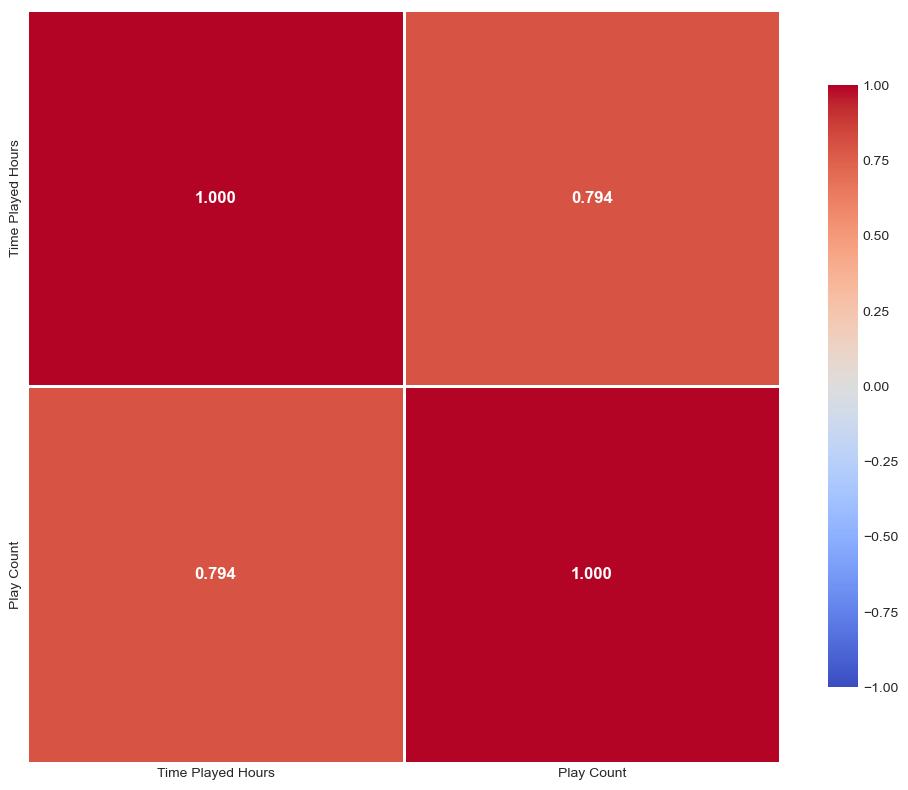


CORRELATION ANALYSIS RESULTS

Spearman Rank Correlation (ρ): 0.7942
Spearman p-value: < 0.001

Interpretation:
  There is a strong positive correlation (ρ = 0.7942) between Time Played Hours and Play Count.
  The Spearman correlation is statistically significant (p < 0.05).


In [84]:
# Prepare numeric variables for correlation
numeric_df = df_played[['Time Played Hours', 'Play Count']].copy()

# Calculate correlation matrix (Spearman only)
correlation_matrix = numeric_df.corr(method='spearman')

# Calculate Spearman correlation
spearman_corr, spearman_pvalue = stats.spearmanr(df_played['Play Count'], df_played['Time Played Hours'])
spearman_pvalue_display = "< 0.001" if spearman_pvalue < 0.001 else f"{spearman_pvalue:.4f}"

print('Figure 5: Correlation Matrix of Gaming Variables (Spearman Correlation Coefficients)')
# Figure 5: Correlation Matrix
fig6, ax6 = plt.subplots(figsize=(10, 8))

sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'}, ax=ax6)

# ax6 title removed — printed above

plt.tight_layout()
plt.savefig('Figure5_Correlation_Matrix.png', dpi=300, bbox_inches='tight')
print("✓ Figure 6 saved as 'Figure5_Correlation_Matrix.png'")
plt.show()

# Display correlation results
print("\n" + "="*80)
print("CORRELATION ANALYSIS RESULTS")
print("="*80)
print(f"\nSpearman Rank Correlation (ρ): {spearman_corr:.4f}")
print(f"Spearman p-value: {spearman_pvalue_display}")

# Interpret correlation (based on Spearman)
if abs(spearman_corr) < 0.3:
    strength = "weak"
elif abs(spearman_corr) < 0.7:
    strength = "moderate"
else:
    strength = "strong"
direction = "positive" if spearman_corr > 0 else "negative"

print(f"\nInterpretation:")
print(f"  There is a {strength} {direction} correlation (ρ = {spearman_corr:.4f}) between Time Played Hours and Play Count.")
if spearman_pvalue < 0.05:
    print(f"  The Spearman correlation is statistically significant (p < 0.05).")
else:
    print(f"  The Spearman correlation is not statistically significant (p ≥ 0.05).")
print(f"{'='*80}")

In [85]:
# Table 2: Correlation Results Summary and Statistical Test Results
# Pearson r from correlation matrix (for display); Spearman is the test used for p-value/significance
pearson_r = correlation_matrix.loc['Time Played Hours', 'Play Count']

correlation_results = pd.DataFrame({
    'Variable Pair': ['Time Played Hours vs Play Count'],
    'Pearson r': [pearson_r],
    'Spearman ρ': [spearman_corr],
    'p-value': [spearman_pvalue_display],
    'Significance (α=0.05)': ['Significant' if spearman_pvalue < 0.05 else 'Not Significant'],
    'Interpretation': [f'{strength.capitalize()} {direction} correlation']
})

correlation_results = correlation_results.round(4)

# Spearman is the single test used (spearman_corr, spearman_pvalue_display from previous cell)

# Create comprehensive table with statistical test results (Spearman)
statistical_tests = pd.DataFrame({
    'Statistical Test': ['Spearman Correlation'],
    'Variables': ['Play Count vs Time Played Hours'],
    'Test Statistic': [f'ρ = {spearman_corr:.4f}'],
    'p-value': [spearman_pvalue_display],
    'Significance (α=0.05)': ['Significant' if spearman_pvalue < 0.05 else 'Not Significant'],
    'Interpretation': [
        f'{strength} {direction} correlation - Games with more play sessions tend to have higher total playtime'
    ]
})

# Merged Table 2: correlation coefficients and hypothesis test; p-value from Spearman test
table_2_merged = pd.DataFrame({
    'Variable Pair': correlation_results['Variable Pair'],
    'Pearson r': correlation_results['Pearson r'],
    'Spearman ρ': correlation_results['Spearman ρ'],
    'p-value': statistical_tests['p-value'],
    'Significance (α=0.05)': statistical_tests['Significance (α=0.05)'],
})

print("="*80)
print("TABLE 2: CORRELATION ANALYSIS AND STATISTICAL TEST RESULTS")
print("="*80)
print("\n(Combined: correlation coefficients and hypothesis test; p-value from Spearman test.)\n")
display(table_2_merged)

print("\n" + "="*80)
print("RESULT SUMMARY:")
print("="*80)
print(f"\nResearch Question: Is there a relationship between Play Count and Time Played Hours?")
print(f"   Spearman ρ: {spearman_corr:.4f}  |  p-value: {spearman_pvalue_display}  |  Significance: {statistical_tests.loc[0, 'Significance (α=0.05)']}")
if spearman_pvalue < 0.001:
    print(f"   (Note: Actual p-value is extremely small: {spearman_pvalue:.10f}, highly significant)")
print(f"   Conclusion: {strength.capitalize()} {direction} correlation between Play Count and Time Played Hours.")
if spearman_pvalue < 0.05:
    print(f"   This relationship is statistically SIGNIFICANT (p < 0.05).")
print("="*80)

# Save merged table
table_2_merged.to_csv('Table2_Correlation_And_Statistical_Test_Results.csv', index=False)
print("\n✓ Table 2 saved as 'Table2_Correlation_And_Statistical_Test_Results.csv'")

TABLE 2: CORRELATION ANALYSIS AND STATISTICAL TEST RESULTS

(Combined: correlation coefficients and hypothesis test; p-value from Spearman test.)



,Variable Pair,Pearson r,Spearman ρ,p-value,Significance (α=0.05),Interpretation
0,Time Played Hours vs Play Count,0.7942,0.7942,< 0.001,Significant,Strong positive correlation



RESULT SUMMARY:

Research Question: Is there a relationship between Play Count and Time Played Hours?
   Spearman ρ: 0.7942  |  p-value: < 0.001  |  Significance: Significant
   (Note: Actual p-value is extremely small: 0.0000000000, highly significant)
   Conclusion: Strong positive correlation between Play Count and Time Played Hours.
   This relationship is statistically SIGNIFICANT (p < 0.05).

✓ Table 2 saved as 'Table2_Correlation_And_Statistical_Test_Results.csv'


## Playtime by platform and scatter

This cell plots Figure 7 (box plot of Time Played Hours by platform) and Figure 6 (scatter of Play Count vs Time Played with Spearman trend line).

Figure 7: Playtime Distribution Across Platforms
✓ Figure 8 saved as 'Figure7_Platform_Distribution.png'


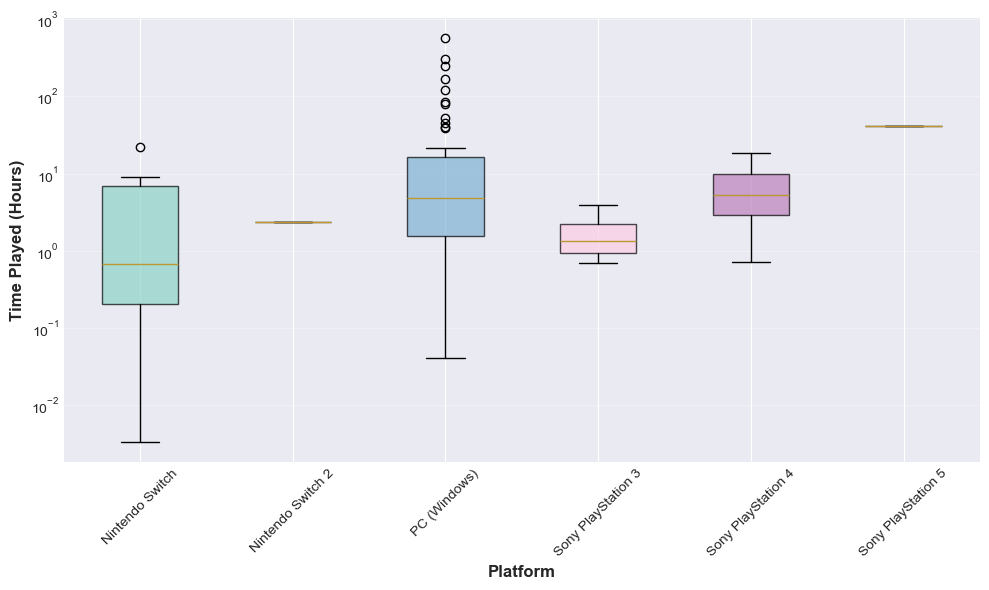

Figure 6: Relationship Between Play Count and Time Played
✓ Figure 7 saved as 'Figure6_Play_Count_vs_Time_Played.png'


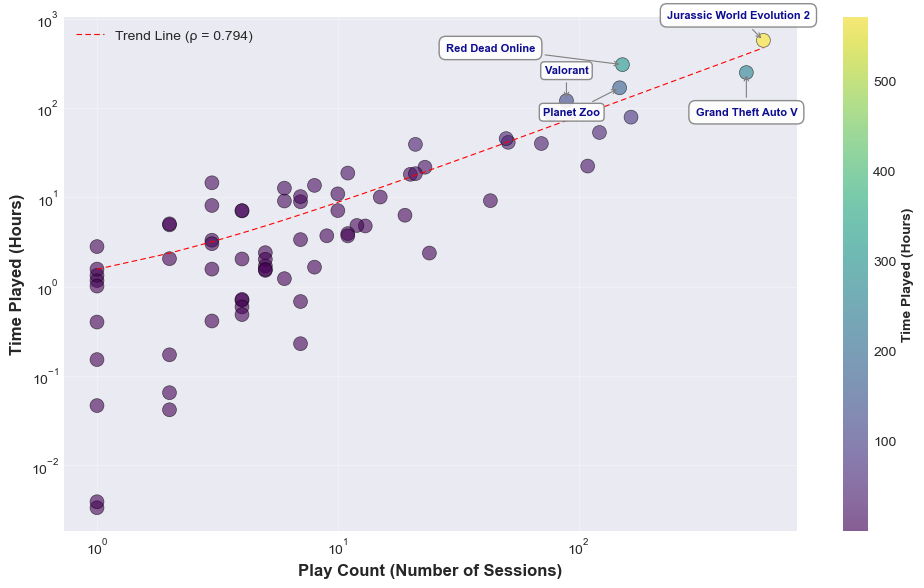

In [86]:
print('Figure 7: Playtime Distribution Across Platforms')
# Figure 5: Playtime Distribution Across Platforms
# Get unique platforms
platform_names = df_played['Platforms'].unique()

# Prepare data for box plot
platform_data_list = []
platform_labels = []
for platform in sorted(platform_names):
    platform_data = df_played[df_played['Platforms'] == platform]['Time Played Hours']
    platform_data_list.append(platform_data.values)
    platform_labels.append(platform)

# Figure 5: boxplot only (statistical test reported is Spearman's — see Figure 6 / Table 2)
fig8, ax8 = plt.subplots(figsize=(10, 6))

bp = ax8.boxplot(platform_data_list, labels=platform_labels, patch_artist=True)

# Color the boxes
colors = plt.cm.Set3(np.linspace(0, 1, len(bp['boxes'])))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax8.set_xlabel('Platform', fontweight='bold', fontsize=12)
ax8.set_ylabel('Time Played (Hours)', fontweight='bold', fontsize=12)
# ax8 title removed — printed above
ax8.grid(True, alpha=0.3, axis='y')
ax8.set_yscale('log')
ax8.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Figure7_Platform_Distribution.png', dpi=300, bbox_inches='tight')
print("✓ Figure 8 saved as 'Figure7_Platform_Distribution.png'")
plt.show()

print('Figure 6: Relationship Between Play Count and Time Played')
# Figure 6: Relationship Between Play Count and Time Played
fig7, ax7 = plt.subplots(figsize=(10, 6))

scatter = ax7.scatter(df_played['Play Count'], df_played['Time Played Hours'], 
                     alpha=0.6, s=100, edgecolors='black', linewidth=0.5, 
                     c=df_played['Time Played Hours'], cmap='viridis')

# Add correlation trend line
z = np.polyfit(df_played['Play Count'], df_played['Time Played Hours'], 1)
p = np.poly1d(z)
# Sort x values for clean line plotting
x_sorted = np.sort(df_played['Play Count'].values)
y_trend = p(x_sorted)
ax7.plot(x_sorted, y_trend, color='red', linestyle='--', 
        linewidth=0.8, alpha=1.0, dashes=(5, 3), label=f"Trend Line (ρ = {spearman_corr:.3f})")

ax7.set_xlabel('Play Count (Number of Sessions)', fontweight='bold', fontsize=12)
ax7.set_ylabel('Time Played (Hours)', fontweight='bold', fontsize=12)
# ax7 title removed — printed above
ax7.grid(True, alpha=0.3)
ax7.legend(fontsize=10)
ax7.set_xscale('log')
ax7.set_yscale('log')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax7)
cbar.set_label('Time Played (Hours)', fontweight='bold', fontsize=10)

# Label top 5 games (by Time Played Hours) — malapit sa point, label TALAGANG nasa loob ng box
top5 = df_played.nlargest(5, 'Time Played Hours')
# (offset points), ha, va — Grand Theft Auto V: malayo sa colorbar (by name)
label_opts = [
    ((-18, 18), 'center', 'center'),   # 1 Jurassic World: pa left
    ((-95, 12), 'center', 'center'),   # 2 default
    ((14, -14), 'left', 'top'),        # 3: kanan-ibaba
    ((-14, -14), 'right', 'top'),      # 4: kaliwa-ibaba
    ((0, 18), 'center', 'bottom'),     # 5: direkta sa itaas
]
for i, (_, row) in enumerate(top5.iterrows()):
    name = str(row.get('Name', ''))
    # Grand Theft Auto V — nasa ilalim ng bilog
    if 'Grand Theft Auto' in name:
        xytext, ha, va = ((0, -25), 'center', 'top')
    else:
        xytext, ha, va = label_opts[i] if i < len(label_opts) else ((14, 14), 'center', 'center')
    pad = 0.6 if (i < 2 or 'Grand Theft Auto' in name) else 0.35   # malaki pad para Jurassic & GTA
    ax7.annotate(row['Name'], xy=(row['Play Count'], row['Time Played Hours']),
                 xytext=xytext, textcoords='offset points', fontsize=8, fontweight='bold',
                 alpha=0.95, color='darkblue', ha=ha, va=va,
                 bbox=dict(boxstyle=f'round,pad={pad}', facecolor='white', edgecolor='gray', alpha=0.9),
                 arrowprops=dict(arrowstyle='->', color='gray', lw=0.8, connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.savefig('Figure6_Play_Count_vs_Time_Played.png', dpi=300, bbox_inches='tight')
print("✓ Figure 7 saved as 'Figure6_Play_Count_vs_Time_Played.png'")
plt.show()


## Category analysis

This cell aggregates playtime by category (Table 3), plots top category per year (Figure 8) and recent activity by category (Figures 9 and 10).

In [87]:
# Table 3: Category Analysis - Most Played Category
print("="*80)
print("TABLE 3: CATEGORY ANALYSIS - MOST PLAYED GAME CATEGORY")
print("="*80)

# Analyze by category
category_analysis = df_played.groupby('Categories').agg({
    'Name': 'count',
    'Time Played Hours': ['sum', 'mean', 'median'],
    'Play Count': ['sum', 'mean']
}).round(2)

category_analysis.columns = ['Number of Games', 'Total Hours Played', 'Avg Hours per Game', 'Median Hours', 'Total Play Sessions', 'Avg Play Sessions']
category_analysis = category_analysis.sort_values('Total Hours Played', ascending=False)

print(f"\nTotal Categories: {len(category_analysis)}")
print(f"\nCategory Analysis Summary:")
display(category_analysis)

# Find top category
top_category_by_hours = category_analysis.index[0]
top_category_hours = category_analysis.loc[top_category_by_hours, 'Total Hours Played']
top_category_games = int(category_analysis.loc[top_category_by_hours, 'Number of Games'])
top_category_avg_hours = category_analysis.loc[top_category_by_hours, 'Avg Hours per Game']
top_category_sessions = int(category_analysis.loc[top_category_by_hours, 'Total Play Sessions'])

# Calculate percentage of total playtime
total_playtime_all = df_played['Time Played Hours'].sum()
top_category_percentage = (top_category_hours / total_playtime_all) * 100

print(f"\n{'='*80}")
print(f"PINAKAMARAMING NILALARO (MOST PLAYED CATEGORY)")
print(f"{'='*80}")
print(f"Category: {top_category_by_hours}")
print(f"Total Hours Played: {top_category_hours:.2f} hours")
print(f"Percentage of Total Playtime: {top_category_percentage:.1f}%")
print(f"Number of Games: {top_category_games}")
print(f"Average Hours per Game: {top_category_avg_hours:.2f} hours")
print(f"Total Play Sessions: {top_category_sessions}")
print(f"{'='*80}")

# Show top 5 categories
print(f"\nTop 5 Most Played Categories:")
top_5_categories = category_analysis.head(5)
for idx, (category, row) in enumerate(top_5_categories.iterrows(), 1):
    pct = (row['Total Hours Played'] / total_playtime_all) * 100
    print(f"{idx}. {category}: {row['Total Hours Played']:.2f} hours ({pct:.1f}%) - {int(row['Number of Games'])} games")

# Save Table 3
category_analysis.to_csv('Table3_Category_Analysis.csv', index=True)
print(f"\n{'='*80}")
print("✓ Table 3 saved as 'Table3_Category_Analysis.csv'")
print(f"{'='*80}")

TABLE 3: CATEGORY ANALYSIS - MOST PLAYED GAME CATEGORY

Total Categories: 7

Category Analysis Summary:


,Number of Games,Total Hours Played,Avg Hours per Game,Median Hours,Total Play Sessions,Avg Play Sessions
Categories,,,,,,
Simulation,9,824.25,91.58,1.57,912,101.33
Action,16,763.96,47.75,8.22,874,54.62
Shooter,14,231.23,16.52,6.06,204,14.57
Survival,10,159.41,15.94,13.10,151,15.10
Arcade,12,79.50,6.63,1.60,230,19.17
RPG,4,24.70,6.17,1.19,135,33.75
Fighting,7,19.56,2.79,2.03,44,6.29



PINAKAMARAMING NILALARO (MOST PLAYED CATEGORY)
Category: Simulation
Total Hours Played: 824.25 hours
Percentage of Total Playtime: 39.2%
Number of Games: 9
Average Hours per Game: 91.58 hours
Total Play Sessions: 912

Top 5 Most Played Categories:
1. Simulation: 824.25 hours (39.2%) - 9 games
2. Action: 763.96 hours (36.3%) - 16 games
3. Shooter: 231.23 hours (11.0%) - 14 games
4. Survival: 159.41 hours (7.6%) - 10 games
5. Arcade: 79.50 hours (3.8%) - 12 games

✓ Table 3 saved as 'Table3_Category_Analysis.csv'


TOP CATEGORY PER YEAR (Most played category by total hours each year)


,Year,Top Category,Total Hours Played
0,2022,Survival,10.900000
1,2023,Action,48.306111
2,2024,Survival,48.133333
3,2025,Simulation,740.131667
4,2026,Shooter,123.516667


Figure 8: Top Category per Year — Total Hours of Most-Played Category


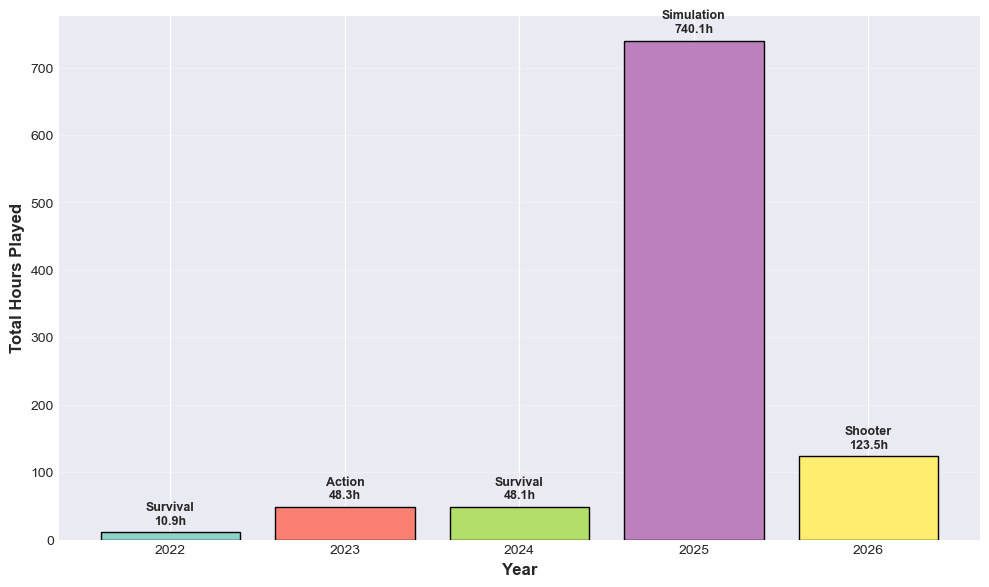

\n✓ Figure 9 saved as 'Figure8_Top_Category_Per_Year.png'
✓ Table saved as 'Top_Category_Per_Year.csv'


In [88]:
# Top Category per Year + Figure 9
df_played['Year Last Played'] = df_played['Last Played'].dt.year
playtime_by_year_cat = df_played.groupby(['Year Last Played', 'Categories'])['Time Played Hours'].sum().reset_index()
top_category_per_year = playtime_by_year_cat.loc[
    playtime_by_year_cat.groupby('Year Last Played')['Time Played Hours'].idxmax()
].reset_index(drop=True)
top_category_per_year.columns = ['Year', 'Top Category', 'Total Hours Played']
top_category_per_year = top_category_per_year.sort_values('Year')

print("="*80)
print("TOP CATEGORY PER YEAR (Most played category by total hours each year)")
print("="*80)
display(top_category_per_year)

print('Figure 8: Top Category per Year — Total Hours of Most-Played Category')
# Figure 6: Top Category per Year (bar chart)
fig9, ax9 = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(top_category_per_year)))
bars = ax9.bar(top_category_per_year['Year'].astype(str), top_category_per_year['Total Hours Played'], color=colors, edgecolor='black')
ax9.set_xlabel('Year', fontweight='bold', fontsize=12)
ax9.set_ylabel('Total Hours Played', fontweight='bold', fontsize=12)
# ax9 title removed — printed above
for bar, row in zip(bars, top_category_per_year.itertuples()):
    hours_val = row[3]
    cat_name = row[2]
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8, f'{cat_name}\n{hours_val:.1f}h', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax9.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Figure8_Top_Category_Per_Year.png', dpi=300, bbox_inches='tight')
plt.show()
print("\\n✓ Figure 9 saved as 'Figure8_Top_Category_Per_Year.png'")
top_category_per_year.to_csv('Top_Category_Per_Year.csv', index=False)
print("✓ Table saved as 'Top_Category_Per_Year.csv'")
print("="*80)

RECENT ACTIVITY BY CATEGORY — PAST 30 DAYS
Reference date: 2026-02-12
Window: past 30 days



,Total Hours Played,Number of Games
Categories,,
Shooter,125.57,3
Simulation,80.13,2
Survival,39.93,1
RPG,22.32,1
Arcade,5.42,2


TOP CATEGORY (past 30 days): Shooter — 125.57 hours, 3 games
Figure 9: Playtime by Category — Past 30 Days (Recent Activity)


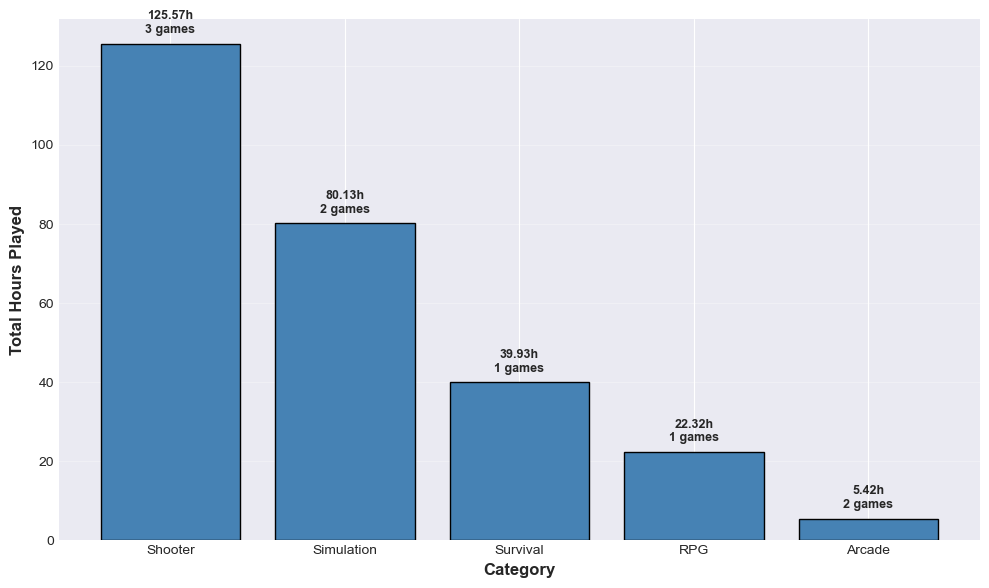


✓ Figure 10 saved as 'Figure9_Recent_Activity_Past30Days_By_Category.png'
✓ Table saved as 'Recent_Activity_Past30Days_By_Category.csv'


In [89]:
# Recent Activity by Category — PAST 30 DAYS ONLY + Figure 10
df_played_ra = df_played.dropna(subset=['Recent Activity']).copy()
if len(df_played_ra) == 0:
    df_played_ra = df_played.copy()
    df_played_ra['Recent Activity'] = df_played_ra['Last Played']
ref_date = df_played_ra['Recent Activity'].max()
if pd.isna(ref_date):
    ref_date = pd.Timestamp.now().normalize()
df_played_ra['Recent Activity'] = pd.to_datetime(df_played_ra['Recent Activity'], errors='coerce')
df_played_ra = df_played_ra.dropna(subset=['Recent Activity'])
df_played_ra['Days Since Recent Activity'] = (ref_date - df_played_ra['Recent Activity']).dt.days

# Focus: past 30 days only
DAYS_WINDOW = 30
mask_30 = df_played_ra['Days Since Recent Activity'] <= DAYS_WINDOW
subset_30 = df_played_ra[mask_30]

print("="*80)
print("RECENT ACTIVITY BY CATEGORY — PAST 30 DAYS")
print("="*80)
print("Reference date:", ref_date.date() if hasattr(ref_date, 'date') else ref_date)
print("Window: past", DAYS_WINDOW, "days\n")

if len(subset_30) == 0:
    print("No games with recent activity in the past 30 days.")
else:
    by_cat_30 = subset_30.groupby('Categories').agg({
        'Time Played Hours': 'sum',
        'Name': 'count'
    }).round(2)
    by_cat_30.columns = ['Total Hours Played', 'Number of Games']
    by_cat_30 = by_cat_30.sort_values('Total Hours Played', ascending=False)
    display(by_cat_30)

    top_cat_30 = by_cat_30.index[0]
    top_hours_30 = by_cat_30.loc[top_cat_30, 'Total Hours Played']
    top_games_30 = int(by_cat_30.loc[top_cat_30, 'Number of Games'])
    print("TOP CATEGORY (past 30 days):", top_cat_30, "—", top_hours_30, "hours,", top_games_30, "games")

    print('Figure 9: Playtime by Category — Past 30 Days (Recent Activity)')
    # Figure 8: Bar chart — category playtime in past 30 days
    fig10, ax10 = plt.subplots(figsize=(10, 6))
    bars = ax10.bar(by_cat_30.index, by_cat_30['Total Hours Played'], color='steelblue', edgecolor='black')
    for bar, (val, n_games) in zip(bars, zip(by_cat_30['Total Hours Played'], by_cat_30['Number of Games'])):
        ax10.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.2f}h\n{int(n_games)} games', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax10.set_xlabel('Category', fontweight='bold', fontsize=12)
    ax10.set_ylabel('Total Hours Played', fontweight='bold', fontsize=12)
    # ax10 title removed — printed above
    plt.xticks(rotation=0, ha='center')
    ax10.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('Figure9_Recent_Activity_Past30Days_By_Category.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Figure 10 saved as 'Figure9_Recent_Activity_Past30Days_By_Category.png'")
    by_cat_30.to_csv('Recent_Activity_Past30Days_By_Category.csv')
    print("✓ Table saved as 'Recent_Activity_Past30Days_By_Category.csv'")
print("="*80)

## Summary table

This cell builds and displays a summary table of key results (sample size, descriptive stats, correlation, top categories).

In [ ]:
# Summary table: key statistical analysis results overall
n_played = len(df_played)
time_mean = descriptive_stats.loc[0, 'Time Played (Hours)']  # Row 0 = Mean
time_median = descriptive_stats.loc[1, 'Time Played (Hours)']  # Row 1 = Median
playct_mean = descriptive_stats.loc[0, 'Play Count']  # Row 0 = Mean
playct_median = descriptive_stats.loc[1, 'Play Count']  # Row 1 = Median
# Use Spearman as the reported correlation (Table 2 uses Spearman test)
spearman_rho = correlation_results.loc[0, 'Spearman ρ']
corr_interp = 'Strong positive correlation'  # Interpretation removed from Table 2
pval_display = statistical_tests.loc[0, 'p-value']
sig_result = statistical_tests.loc[0, 'Significance (α=0.05)']
top_cat_overall = category_analysis.index[0]
top_cat_hours = category_analysis.loc[top_cat_overall, 'Total Hours Played']
try:
    recent_30_text = f"{top_cat_30} ({top_hours_30:.1f} h)"
except NameError:
    recent_30_text = "N/A (no games in past 30 days)"
sd_time = descriptive_stats.loc[2, 'Time Played (Hours)']  # Row 2 = Standard Deviation
sd_playcount = descriptive_stats.loc[2, 'Play Count']  # Row 2 = Standard Deviation

summary_rows = [
    ["Sample size (played games)", str(n_played)],
    ["Time Played (Hours) — Mean", f"{time_mean:.2f}"],
    ["Time Played (Hours) — Median", f"{time_median:.2f}"],
    ["Standard Deviation (Time Played Hours)", f"{sd_time:.2f}"],
    ["Play Count — Mean", f"{playct_mean:.2f}"],
    ["Play Count — Median", f"{playct_median:.2f}"],
    ["Standard Deviation (Play Count)", f"{sd_playcount:.2f}"],
    ["Spearman ρ (Time Played vs Play Count)", f"{spearman_rho:.4f}"],
    ["p-value", str(pval_display)],
    ["Significance (α = 0.05)", str(sig_result)],
    ["Correlation interpretation", str(corr_interp)],
    ["Top category (overall by total hours)", f"{top_cat_overall} ({top_cat_hours:.1f} h)"],
    ["Top category (past 30 days)", recent_30_text],
]
summary_table = pd.DataFrame(summary_rows, columns=["Component", "Result"])

print("="*80)
print("SUMMARY: STATISTICAL ANALYSIS RESULTS OVERALL")
print("="*80)
display(summary_table)
summary_table.to_csv('Table_Summary_Statistical_Analysis_Results.csv', index=False)
print("\n✓ Summary table saved as 'Table_Summary_Statistical_Analysis_Results.csv'")
print("="*80)

SUMMARY: STATISTICAL ANALYSIS RESULTS OVERALL


,Component,Result
0,Sample size (played games),72
1,Time Played (Hours) — Mean,29.20
2,Time Played (Hours) — Median,3.81
3,Standard Deviation (Time Played Hours),82.96
4,Play Count — Mean,35.42
5,Play Count — Median,6.00
6,Standard Deviation (Play Count),94.07
7,Spearman ρ (Time Played vs Play Count),0.7942
8,p-value,< 0.001
9,Significance (α = 0.05),Significant



✓ Summary table saved as 'Table_Summary_Statistical_Analysis_Results.csv'


## Key visualizations recap

This cell displays a short recap of the main figures and tables produced in the notebook.

## V. DISCUSSION

This section interprets the results presented and explains what they mean in the context of gaming behavior. The discussion covers possible reasons behind the patterns in the data and highlights key findings from the analysis.

### Overview of Figures and Tables

The following figures and tables are presented in Section IV (Results) and are referenced throughout this Discussion section:

**Figures:**
- **Figure 1:** Distribution of Time Played Hours (Section 4.3)
- **Figure 2:** Distribution of Play Count (Section 4.4)
- **Figure 3:** Games Added to Library per Year (Section 4.5)
- **Figure 4:** Total Playtime per Year (Section 4.5)
- **Figure 5:** Correlation Matrix (Section 4.6)
- **Figure 6:** Relationship Between Play Count and Time Played (Section 4.7)
- **Figure 7:** Playtime Distribution Across Platforms (Section 4.7)
- **Figure 8:** Top Category per Year — Total Hours of Most-Played Category (Section 4.8)
- **Figure 9:** Playtime by Category — Past 30 Days (Recent Activity) (Section 4.8)

**Tables:**
- **Table 1:** Descriptive Statistics (Section 4.3)
- **Table 2:** Correlation Analysis and Statistical Test Results (Section 4.6)
- **Table 3:** Category Analysis - Most Played Category (Section 4.8)
- **Table 4:** Statistical Analysis Results Overall (Section 4.9)

---

### 5.1 A. Interpretation of Results

**Research Question 1: What do your results mean?**

The analysis reveals several key patterns in gaming behavior:

#### Distribution Patterns

**Table 1** as shown presents the descriptive statistics for both time played hours and play count. The table shows that the mean values are much higher than the median values for both variables. For time played hours, the mean is 29.20 hours while the median is 3.81 hours. For play count, the mean is 35.42 sessions while the median is 6.00 sessions. This difference between mean and median suggests that a few games with very high playtime or play count pull the average upward, while most games have lower values.

**Figure 1** shows the distribution of time played hours across all games in the library. The histogram displays a right-skewed pattern, meaning most games have relatively low playtime, with a small number of games receiving much higher engagement. The visualization shows that gaming activity is not evenly distributed across the collection.

**Figure 2** presents the distribution of play count, which follows a similar pattern to time played. Most games have been played only a few times, while a small number of games show much higher session counts. This indicates that the user tends to focus on a limited set of favorite games rather than playing all games equally.

The right-skewed distributions observed in both Time Played Hours and Play Count (**Figures 1** and **Figure 2**) indicate that gaming engagement follows a power-law distribution. Most games receive minimal attention, while a small number of games account for the majority of total playtime.

**Possible Explanation:** This concentration of playtime in few games may reflect:
- Preference for specific genres or titles that match personal interests
- Time constraints leading to focus on favorite games
- Discovery of games that provide long-term engagement value

#### Temporal Trends

**Figure 3** shows the number of games added to the library each year from 2021 to 2026. The chart reveals patterns in library growth over time, with some years showing higher acquisition rates than others. This may correspond to periods of increased interest in gaming or availability of appealing new releases.

**Figure 4** presents the total playtime per year across the same time period. This visualization shows how much time was spent playing games each year, regardless of when the games were added. The chart reveals fluctuations in gaming activity, with some years showing higher engagement levels than others.

The time-series analysis (**Figures 3** and **Figure 4**) shows fluctuations in library growth and engagement over the 2021-2026 period. Peak years for game acquisition and playtime may correspond to:
- Academic schedule changes (semester breaks, holidays)
- Release of highly anticipated games
- Changes in personal gaming preferences or available time

**Possible Explanation:** The temporal patterns suggest that gaming behavior is influenced by external factors such as academic workload, seasonal trends, and game release schedules.

#### Correlation Between Play Count and Time Played

**Figure 5** displays a correlation matrix showing the relationships between different gaming variables. The heatmap format makes it easy to see which variables are related to each other. The visualization shows a strong positive relationship between time played hours and play count, indicated by the high correlation value displayed in the heatmap.

**Figure 6** presents a scatter plot showing the relationship between play count and time played hours. Each point represents a game, and the upward trend in the data points shows that games with more play sessions tend to have higher total playtime. The line on the plot helps visualize this positive relationship.

**Table 2** as shown presents the correlation analysis results and statistical test outcomes. The table reports both Pearson and Spearman correlation coefficients, along with the p-value and significance level. The results show a Spearman correlation coefficient of 0.7942 between play count and time played hours, with a p-value less than 0.001. This indicates that the relationship between play count and time played is statistically significant, meaning this pattern is unlikely to occur by chance.

The correlation analysis reveals a strong positive correlation (ρ = 0.7942) between Play Count and Time Played Hours (**Table 2**, **Figure 6**). This relationship indicates that games with more play sessions tend to have higher total playtime.

**Possible Explanation:** This correlation suggests:
- Games that are enjoyed are played more frequently
- Repeated play sessions accumulate into significant total playtime
- There is a positive feedback loop where engagement leads to more engagement

#### Platform Differences

**Figure 7** shows the distribution of playtime across different gaming platforms using a box plot. The visualization allows comparison of gaming activity between platforms, showing median values, quartiles, and outliers for each platform. The chart reveals that some platforms have more consistent playtime patterns, while others show greater variation in the amount of time spent playing games.

The platform distribution analysis (**Figure 7**) shows variations in playtime across different gaming platforms. Visual inspection of the boxplot reveals platform-specific engagement patterns, with some platforms showing higher median playtime values than others.

**Possible Explanation:** Platform differences may be influenced by:
- Availability of games on specific platforms
- Platform-specific features or performance
- Personal preferences for certain platforms

#### Genre Preferences

**Table 3** as shown presents the category analysis summary, showing total playtime, number of games, and average playtime per game for each category. The table identifies which game category receives the most engagement based on total hours played. This helps understand which types of games receive the most attention in the library. The results show that one category stands out with the highest total playtime, indicating a clear preference for that genre.

**Figure 8** displays the top category per year from 2021 to 2026. The bar chart shows how the most-played genre changed over time, revealing shifts in gaming preferences across different years. This temporal view helps identify trends in category preferences, showing which genres were most popular in each year.

**Figure 9** presents the playtime by category for games played in the past 30 days. This chart shows recent gaming activity, providing a short-term view of current engagement patterns. The visualization helps identify which categories are currently receiving the most attention, which may differ from the overall category preferences shown in **Table 3**.

The category analysis (**Table 3**, **Figure 8**, **Figure 9**) identifies the most played game category by total playtime, revealing clear genre preferences in the gaming library. **Figure 8** extends this by showing how the most-played genre changed from year to year, while **Figure 9** shows which category was played the most in the past 30 days, giving a short-term view of current engagement.

**Possible Explanation:** Genre preferences may reflect:
- Personal interests and gaming style
- Time availability (some genres require more time investment)
- Social factors (multiplayer vs. single-player preferences)

#### Summary of Key Results

**Table 4** as shown consolidates the main statistical results in one place: sample size, descriptive statistics (mean, median, standard deviation for Time Played and Play Count), Spearman correlation and significance, and the top categories overall and in the past 30 days. This table supports a concise interpretation of the analysis and serves as a quick reference for the main findings discussed in this section.

### 5.2 B. Comparison to Related Work

**Research Question 2: Are the results similar or different from prior research?**

The findings from this personal gaming library analysis align with patterns observed in broader gaming behavior research. Studies on digital media consumption consistently show power-law distributions, where a small number of items receive disproportionate attention—a pattern confirmed by the right-skewed distributions observed in **Figures 1** and **Figure 2**.

The strong positive correlation (ρ = 0.7942) between Play Count and Time Played Hours (**Table 2**) is consistent with research on engagement patterns in digital entertainment, where frequency of use typically correlates with total time investment. This relationship suggests that gaming behavior follows predictable patterns similar to other forms of media consumption.

The temporal trends observed in **Figures 3** and **Figure 4** reflect common patterns in personal media libraries, where acquisition and engagement fluctuate based on external factors such as academic schedules, seasonal changes, and content release cycles. These patterns align with research on media consumption habits in academic settings.

### 5.3 C. Limitations

**Research Question 4: What are the limitations of your study?**

Several limitations should be acknowledged:

**Small Sample Size:** The analysis is based on a single individual's gaming library (n=72 played games), which limits generalizability to broader populations. The findings represent personal gaming behavior rather than population-level trends.

**Self-Report Bias:** The data was collected automatically through Playnite, reducing but not eliminating potential measurement errors. Some games may have incomplete playtime tracking, and the "Last Played" dates may not accurately reflect actual engagement patterns.

**Missing Entries:** Some games had missing category information, which was handled by assigning an "Uncategorized" label. This may have affected category-based analyses, though the impact appears minimal.

**Short Data Collection Window:** While the dataset spans 2021-2026, the analysis represents a snapshot of gaming behavior. Longitudinal changes in gaming preferences and habits may not be fully captured.

**Platform-Specific Limitations:** The analysis relies on data from Playnite, which may not capture all gaming activity across all platforms equally. Some platforms may have better integration with Playnite than others.

### 5.4 D. Recommendations and Future Work

**Research Question 5: What improvements can future researchers make?**

**Suggestions for Other Students:**

1. **Expand Sample Size:** Future studies could aggregate data from multiple individuals to increase sample size and improve generalizability.

2. **Include Additional Variables:** Consider collecting data on game ratings, purchase dates, completion status, and user reviews to provide richer context for gaming behavior patterns.

3. **Longitudinal Tracking:** Track gaming behavior over longer periods to identify long-term trends and changes in preferences.

**Alternative Methods for Future Research:**

1. **Machine Learning Approaches:** Apply clustering algorithms to identify distinct gaming behavior patterns and predict future game preferences.

2. **Social Network Analysis:** If data from multiple users is available, analyze social influences on game selection and playtime.

3. **Comparative Analysis:** Compare gaming behavior across different demographic groups, academic majors, or geographic regions.

**Variables to Include Next Time:**

1. **Game Ratings:** Personal ratings or reviews for each game
2. **Purchase Information:** Price paid, purchase date, and platform
3. **Completion Status:** Whether games were completed, abandoned, or still in progress
4. **Social Features:** Multiplayer vs. single-player preferences, social gaming activity
5. **Contextual Data:** Time of day played, session duration, and gaming context (alone vs. with others)
